### EDA and Feature Engineering on AIR Quality dataset....

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv('E:\\Work\\OneDrive - Rapifuzz Private Limited\\Desktop\\Ayush\\Data_Science\\EDA\\AirQuality.csv', sep=';')

In [3]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN


### DATA Cleaning

In [4]:
df.shape

(9471, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   object 
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   object 
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   object 
 13  RH             9357 non-null   object 
 14  AH             9357 non-null   object 
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(10), object(7)
memory usage: 1.2+ MB


In [6]:
df.drop(['Unnamed: 15', 'Unnamed: 16'], axis=1, inplace=True)
df.isnull().sum()

Date             114
Time             114
CO(GT)           114
PT08.S1(CO)      114
NMHC(GT)         114
C6H6(GT)         114
PT08.S2(NMHC)    114
NOx(GT)          114
PT08.S3(NOx)     114
NO2(GT)          114
PT08.S4(NO2)     114
PT08.S5(O3)      114
T                114
RH               114
AH               114
dtype: int64

In [7]:
df.dropna(inplace=True)
df.shape

(9357, 15)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,PT08.S1(CO),NMHC(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3)
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,1048.990061,-159.090093,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032
std,329.832710,139.789093,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,921.000000,-200.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000
50%,1053.000000,-200.000000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000
75%,1221.000000,-200.000000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000
max,2040.000000,1189.000000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000


In [10]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Time'] = pd.to_datetime(df['Time'], format='%H.%M.%S').dt.time

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   datetime64[ns]
 1   Time           9357 non-null   object        
 2   CO(GT)         9357 non-null   object        
 3   PT08.S1(CO)    9357 non-null   float64       
 4   NMHC(GT)       9357 non-null   float64       
 5   C6H6(GT)       9357 non-null   object        
 6   PT08.S2(NMHC)  9357 non-null   float64       
 7   NOx(GT)        9357 non-null   float64       
 8   PT08.S3(NOx)   9357 non-null   float64       
 9   NO2(GT)        9357 non-null   float64       
 10  PT08.S4(NO2)   9357 non-null   float64       
 11  PT08.S5(O3)    9357 non-null   float64       
 12  T              9357 non-null   object        
 13  RH             9357 non-null   object        
 14  AH             9357 non-null   object        
dtypes: datetime64[ns](1), floa

In [12]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,2004-03-10,19:00:00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,2004-03-10,20:00:00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,2004-03-10,21:00:00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,2004-03-10,22:00:00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"


In [13]:
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year

In [14]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,day,month,year
0,2004-03-10,18:00:00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",10,3,2004
1,2004-03-10,19:00:00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",10,3,2004
2,2004-03-10,20:00:00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",10,3,2004
3,2004-03-10,21:00:00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",10,3,2004
4,2004-03-10,22:00:00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",10,3,2004


In [15]:
df['Time'].unique()
df['hour'] = df['Time'].apply(lambda x: x.hour)
df['minute'] = df['Time'].apply(lambda x: x.minute)
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,day,month,year,hour,minute
0,2004-03-10,18:00:00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",10,3,2004,18,0
1,2004-03-10,19:00:00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",10,3,2004,19,0
2,2004-03-10,20:00:00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",10,3,2004,20,0
3,2004-03-10,21:00:00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",10,3,2004,21,0
4,2004-03-10,22:00:00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",10,3,2004,22,0


In [16]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'day', 'month', 'year', 'hour',
       'minute'],
      dtype='object')

In [17]:
df['minute'].unique()

array([0])

In [18]:
df.drop(['Date', 'Time', 'minute'], axis=1, inplace=True)

In [19]:
df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,day,month,year,hour
0,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",10,3,2004,18
1,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",10,3,2004,19
2,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",10,3,2004,20
3,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",10,3,2004,21
4,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",10,3,2004,22


In [20]:
df['CO(GT)'].unique()

array(['2,6', '2', '2,2', '1,6', '1,2', '1', '0,9', '0,6', '-200', '0,7',
       '1,1', '1,7', '1,5', '1,9', '2,9', '4,8', '6,9', '6,1', '3,9',
       '1,4', '0,8', '4,4', '3,1', '2,7', '2,1', '2,5', '2,8', '2,4',
       '3,7', '6,6', '3,5', '5,4', '3,2', '4,1', '3,6', '2,3', '4,2',
       '1,8', '3', '4,6', '5,9', '3,4', '5,5', '8,1', '5,8', '8', '6,5',
       '1,3', '5,3', '3,3', '4', '3,8', '5,1', '0,5', '4,3', '5', '7,6',
       '6,7', '5,7', '4,7', '4,5', '6,2', '0,4', '0,3', '5,2', '4,9',
       '6,3', '7,3', '6,4', '6', '5,6', '7,2', '0,2', '0,1', '7,5', '7',
       '7,7', '6,8', '8,4', '7,9', '9,5', '9,2', '8,7', '7,8', '10,2',
       '8,3', '8,6', '11,9', '11,5', '10,1', '9,4', '9,9', '7,4', '9,3',
       '9,1', '8,5', '1,0', '3,0', '5,0', '2,0', '-200,0', '4,0', '6,0',
       '7,1'], dtype=object)

In [21]:
comma = df[df['CO(GT)'].str.contains(',')]

In [22]:
comma.shape

(7220, 17)

In [23]:
not_comma = df[~df['CO(GT)'].str.contains(',')]

In [24]:
not_comma.shape

(2137, 17)

In [25]:
comma.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,day,month,year,hour
0,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",10,3,2004,18
2,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",10,3,2004,20
3,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",10,3,2004,21
4,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",10,3,2004,22
5,"1,2",1197.0,38.0,"4,7",750.0,89.0,1337.0,96.0,1393.0,949.0,"11,2","59,2","0,7848",10,3,2004,23


In [26]:
comma['CO(GT)'].unique()

array(['2,6', '2,2', '1,6', '1,2', '0,9', '0,6', '0,7', '1,1', '1,7',
       '1,5', '1,9', '2,9', '4,8', '6,9', '6,1', '3,9', '1,4', '0,8',
       '4,4', '3,1', '2,7', '2,1', '2,5', '2,8', '2,4', '3,7', '6,6',
       '3,5', '5,4', '3,2', '4,1', '3,6', '2,3', '4,2', '1,8', '4,6',
       '5,9', '3,4', '5,5', '8,1', '5,8', '6,5', '1,3', '5,3', '3,3',
       '3,8', '5,1', '0,5', '4,3', '7,6', '6,7', '5,7', '4,7', '4,5',
       '6,2', '0,4', '0,3', '5,2', '4,9', '6,3', '7,3', '6,4', '5,6',
       '7,2', '0,2', '0,1', '7,5', '7,7', '6,8', '8,4', '7,9', '9,5',
       '9,2', '8,7', '7,8', '10,2', '8,3', '8,6', '11,9', '11,5', '10,1',
       '9,4', '9,9', '7,4', '9,3', '9,1', '8,5', '1,0', '3,0', '5,0',
       '2,0', '-200,0', '4,0', '6,0', '7,1'], dtype=object)

In [27]:
comma['CO'] = comma['CO(GT)'].str.split(',').str[0]
comma['GT'] = comma['CO(GT)'].str.split(',').str[1]

C:\Users\AyushRanjanSoni\AppData\Local\Temp\ipykernel_19360\126960644.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comma['CO'] = comma['CO(GT)'].str.split(',').str[0]
C:\Users\AyushRanjanSoni\AppData\Local\Temp\ipykernel_19360\126960644.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comma['GT'] = comma['CO(GT)'].str.split(',').str[1]


In [28]:
comma.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,day,month,year,hour,CO,GT
0,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",10,3,2004,18,2,6
2,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",10,3,2004,20,2,2
3,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",10,3,2004,21,2,2
4,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",10,3,2004,22,1,6
5,"1,2",1197.0,38.0,"4,7",750.0,89.0,1337.0,96.0,1393.0,949.0,"11,2","59,2","0,7848",10,3,2004,23,1,2


In [29]:
not_comma.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,day,month,year,hour
1,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",10,3,2004,19
7,1,1136.0,31.0,"3,3",672.0,62.0,1453.0,76.0,1333.0,730.0,"10,7","60,0","0,7702",11,3,2004,1
10,-200,1011.0,14.0,"1,3",527.0,21.0,1818.0,34.0,1197.0,445.0,"10,1","60,5","0,7465",11,3,2004,4
14,2,1333.0,64.0,"8,0",900.0,174.0,1136.0,112.0,1517.0,1102.0,"10,8","57,4","0,7408",11,3,2004,8
29,1,913.0,26.0,"2,6",629.0,47.0,1565.0,53.0,1252.0,552.0,"8,2","60,8","0,6657",11,3,2004,23


In [30]:
not_comma['CO'] = not_comma['CO(GT)']
not_comma['GT'] = np.nan

C:\Users\AyushRanjanSoni\AppData\Local\Temp\ipykernel_19360\3391184781.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  not_comma['CO'] = not_comma['CO(GT)']
C:\Users\AyushRanjanSoni\AppData\Local\Temp\ipykernel_19360\3391184781.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  not_comma['GT'] = np.nan


In [31]:
not_comma.shape

(2137, 19)

In [32]:
not_comma.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,day,month,year,hour,CO,GT
1,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",10,3,2004,19,2,NaN
7,1,1136.0,31.0,"3,3",672.0,62.0,1453.0,76.0,1333.0,730.0,"10,7","60,0","0,7702",11,3,2004,1,1,NaN
10,-200,1011.0,14.0,"1,3",527.0,21.0,1818.0,34.0,1197.0,445.0,"10,1","60,5","0,7465",11,3,2004,4,-200,NaN
14,2,1333.0,64.0,"8,0",900.0,174.0,1136.0,112.0,1517.0,1102.0,"10,8","57,4","0,7408",11,3,2004,8,2,NaN
29,1,913.0,26.0,"2,6",629.0,47.0,1565.0,53.0,1252.0,552.0,"8,2","60,8","0,6657",11,3,2004,23,1,NaN


In [33]:
df_copy = pd.concat([comma, not_comma], ignore_index=True)

In [34]:
df_copy.shape

(9357, 19)

In [35]:
df.shape

(9357, 17)

In [36]:
df_copy.drop(['CO(GT)'], axis=1, inplace=True)
df_copy.head()

,PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,day,month,year,hour,CO,GT
0,1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",10,3,2004,18,2,6
1,1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",10,3,2004,20,2,2
2,1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",10,3,2004,21,2,2
3,1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",10,3,2004,22,1,6
4,1197.0,38.0,"4,7",750.0,89.0,1337.0,96.0,1393.0,949.0,"11,2","59,2","0,7848",10,3,2004,23,1,2


In [37]:
for col in df_copy.columns:
    print(df_copy[col].value_counts())
    print('..................................................')

PT08.S1(CO)
-200.0     366
 973.0      30
 1100.0     28
 925.0      26
 938.0      26
          ... 
 1572.0      1
 1602.0      1
 717.0       1
 1628.0      1
 721.0       1
Name: count, Length: 1042, dtype: int64
..................................................
NMHC(GT)
-200.0    8443
 66.0       14
 40.0        9
 29.0        9
 93.0        8
          ... 
 501.0       1
 642.0       1
 265.0       1
 344.0       1
 170.0       1
Name: count, Length: 430, dtype: int64
..................................................
C6H6(GT)
-200,0    366
3,6        84
2,8        82
3,8        79
4,0        78
         ... 
43,7        1
34,8        1
41,0        1
44,9        1
42,8        1
Name: count, Length: 408, dtype: int64
..................................................
PT08.S2(NMHC)
-200.0     366
 853.0      25
 800.0      23
 859.0      23
 880.0      23
          ... 
 511.0       1
 447.0       1
 476.0       1
 1633.0      1
 1400.0      1
Name: count, Length: 1246, dtype: in

In [38]:
df_copy['C6H6(GT)'] = df_copy['C6H6(GT)'].str.replace(',', '.')
df_copy['T'] = df_copy['T'].str.replace(',', '.')
df_copy['RH'] = df_copy['RH'].str.replace(',', '.')
df_copy['AH'] = df_copy['AH'].str.replace(',', '.')

In [39]:
df_copy.head()

,PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,day,month,year,hour,CO,GT
0,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,10,3,2004,18,2,6
1,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,10,3,2004,20,2,2
2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,10,3,2004,21,2,2
3,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,10,3,2004,22,1,6
4,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848,10,3,2004,23,1,2


In [40]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PT08.S1(CO)    9357 non-null   float64
 1   NMHC(GT)       9357 non-null   float64
 2   C6H6(GT)       9357 non-null   object 
 3   PT08.S2(NMHC)  9357 non-null   float64
 4   NOx(GT)        9357 non-null   float64
 5   PT08.S3(NOx)   9357 non-null   float64
 6   NO2(GT)        9357 non-null   float64
 7   PT08.S4(NO2)   9357 non-null   float64
 8   PT08.S5(O3)    9357 non-null   float64
 9   T              9357 non-null   object 
 10  RH             9357 non-null   object 
 11  AH             9357 non-null   object 
 12  day            9357 non-null   int32  
 13  month          9357 non-null   int32  
 14  year           9357 non-null   int32  
 15  hour           9357 non-null   int64  
 16  CO             9357 non-null   object 
 17  GT             7220 non-null   object 
dtypes: float

In [41]:
columns = df_copy.select_dtypes(include=['object']).columns
for col in columns:
    df_copy[col] = df_copy[col].astype(float)

In [42]:
df_copy.shape

(9357, 18)

In [43]:
df_copy.head()

,PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,day,month,year,hour,CO,GT
0,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,10,3,2004,18,2.0,6.0
1,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,10,3,2004,20,2.0,2.0
2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,10,3,2004,21,2.0,2.0
3,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,10,3,2004,22,1.0,6.0
4,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848,10,3,2004,23,1.0,2.0


### Outerlier Detection and Removing from data

In [44]:
def outlier(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)][column]

In [45]:
df_copy['CO'] = outlier(df_copy,'CO')

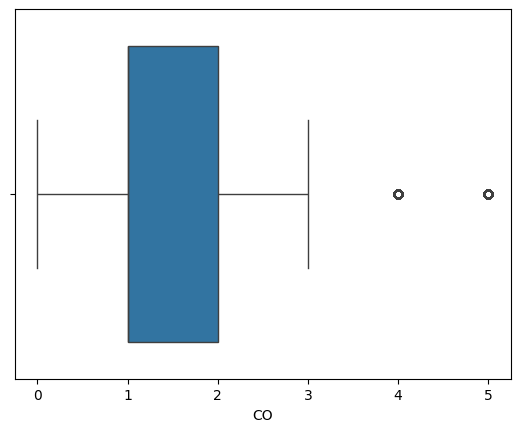

In [46]:
sns.boxplot(x=df_copy['CO'])
plt.show()

In [47]:
min, q1, median, q3, max = df_copy['CO'].quantile([0, 0.25, 0.5, 0.75, 1])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [48]:
lower_bound, upper_bound

(-0.5, 3.5)

In [49]:
min, q1, median, q3, max

(0.0, 1.0, 1.0, 2.0, 5.0)

In [50]:
df_copy['CO'].unique()

array([ 2.,  1.,  0.,  4., nan,  3.,  5.])

In [51]:
df_copy.isnull().sum()

PT08.S1(CO)         0
NMHC(GT)            0
C6H6(GT)            0
PT08.S2(NMHC)       0
NOx(GT)             0
PT08.S3(NOx)        0
NO2(GT)             0
PT08.S4(NO2)        0
PT08.S5(O3)         0
T                   0
RH                  0
AH                  0
day                 0
month               0
year                0
hour                0
CO               1848
GT               2137
dtype: int64

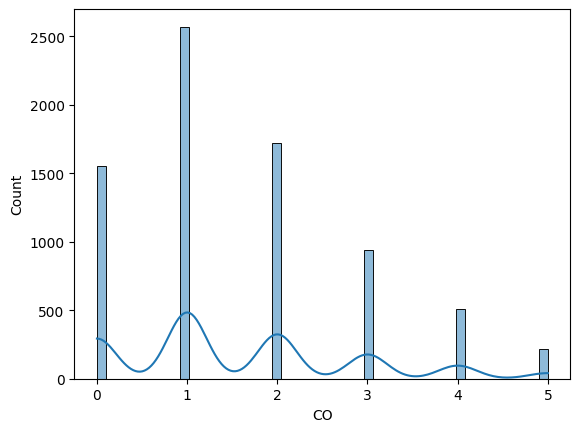

In [52]:
sns.histplot(df_copy['CO'], kde=True)
plt.show()

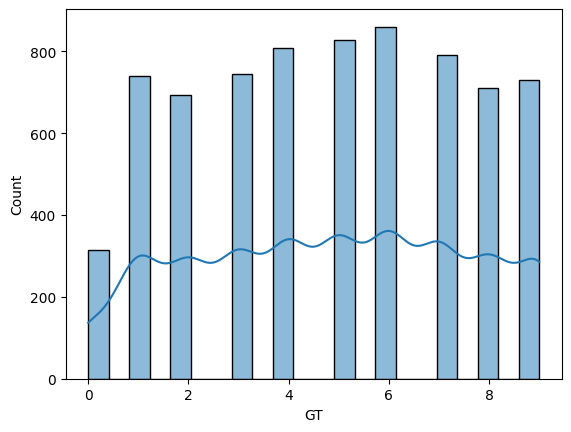

In [53]:
sns.histplot(df_copy['GT'], kde=True)
plt.show()

In [54]:
df_copy['GT'].median()

np.float64(5.0)

In [55]:
df_copy['CO'].median()

np.float64(1.0)

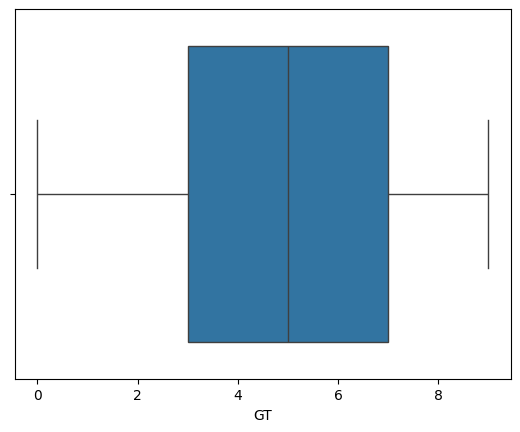

In [56]:
sns.boxplot(x=df_copy['GT'])
plt.show()

In [57]:
df_copy['GT'] = df_copy['GT'].fillna(df_copy['GT'].mean())
df_copy['CO'] = df_copy['CO'].fillna(df_copy['CO'].median())

In [58]:
df_copy.isnull().sum()

PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
day              0
month            0
year             0
hour             0
CO               0
GT               0
dtype: int64

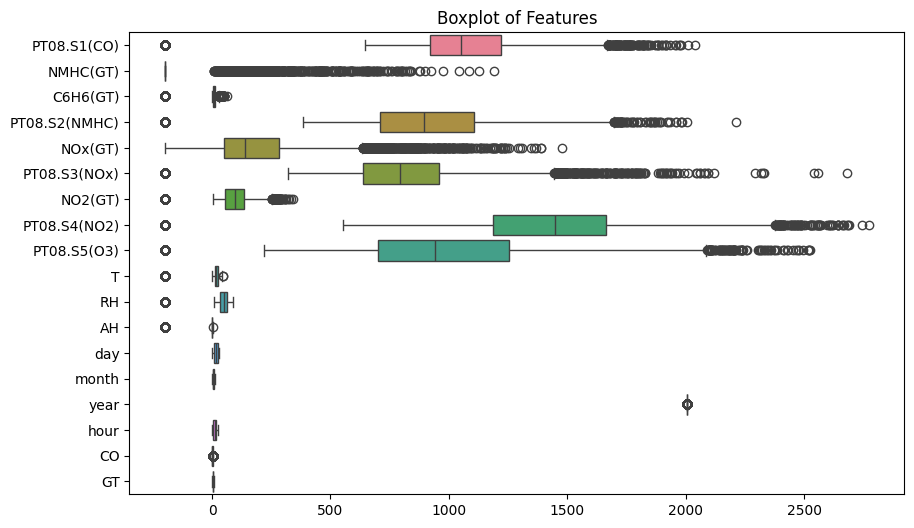

In [59]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_copy, orient='h')
plt.title('Boxplot of Features')
plt.show()

In [60]:
data = outlier(df_copy,'PT08.S1(CO)')
data.shape

(8873,)

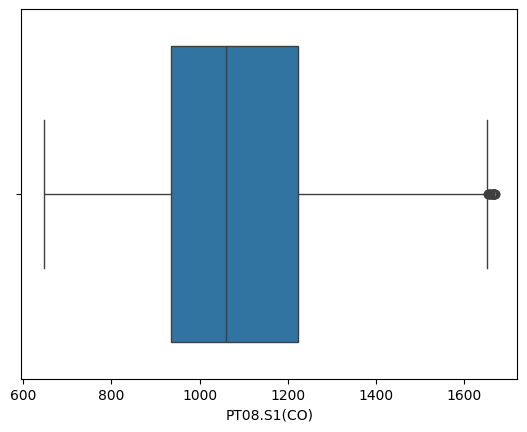

In [61]:
sns.boxplot(x=data)
plt.show()

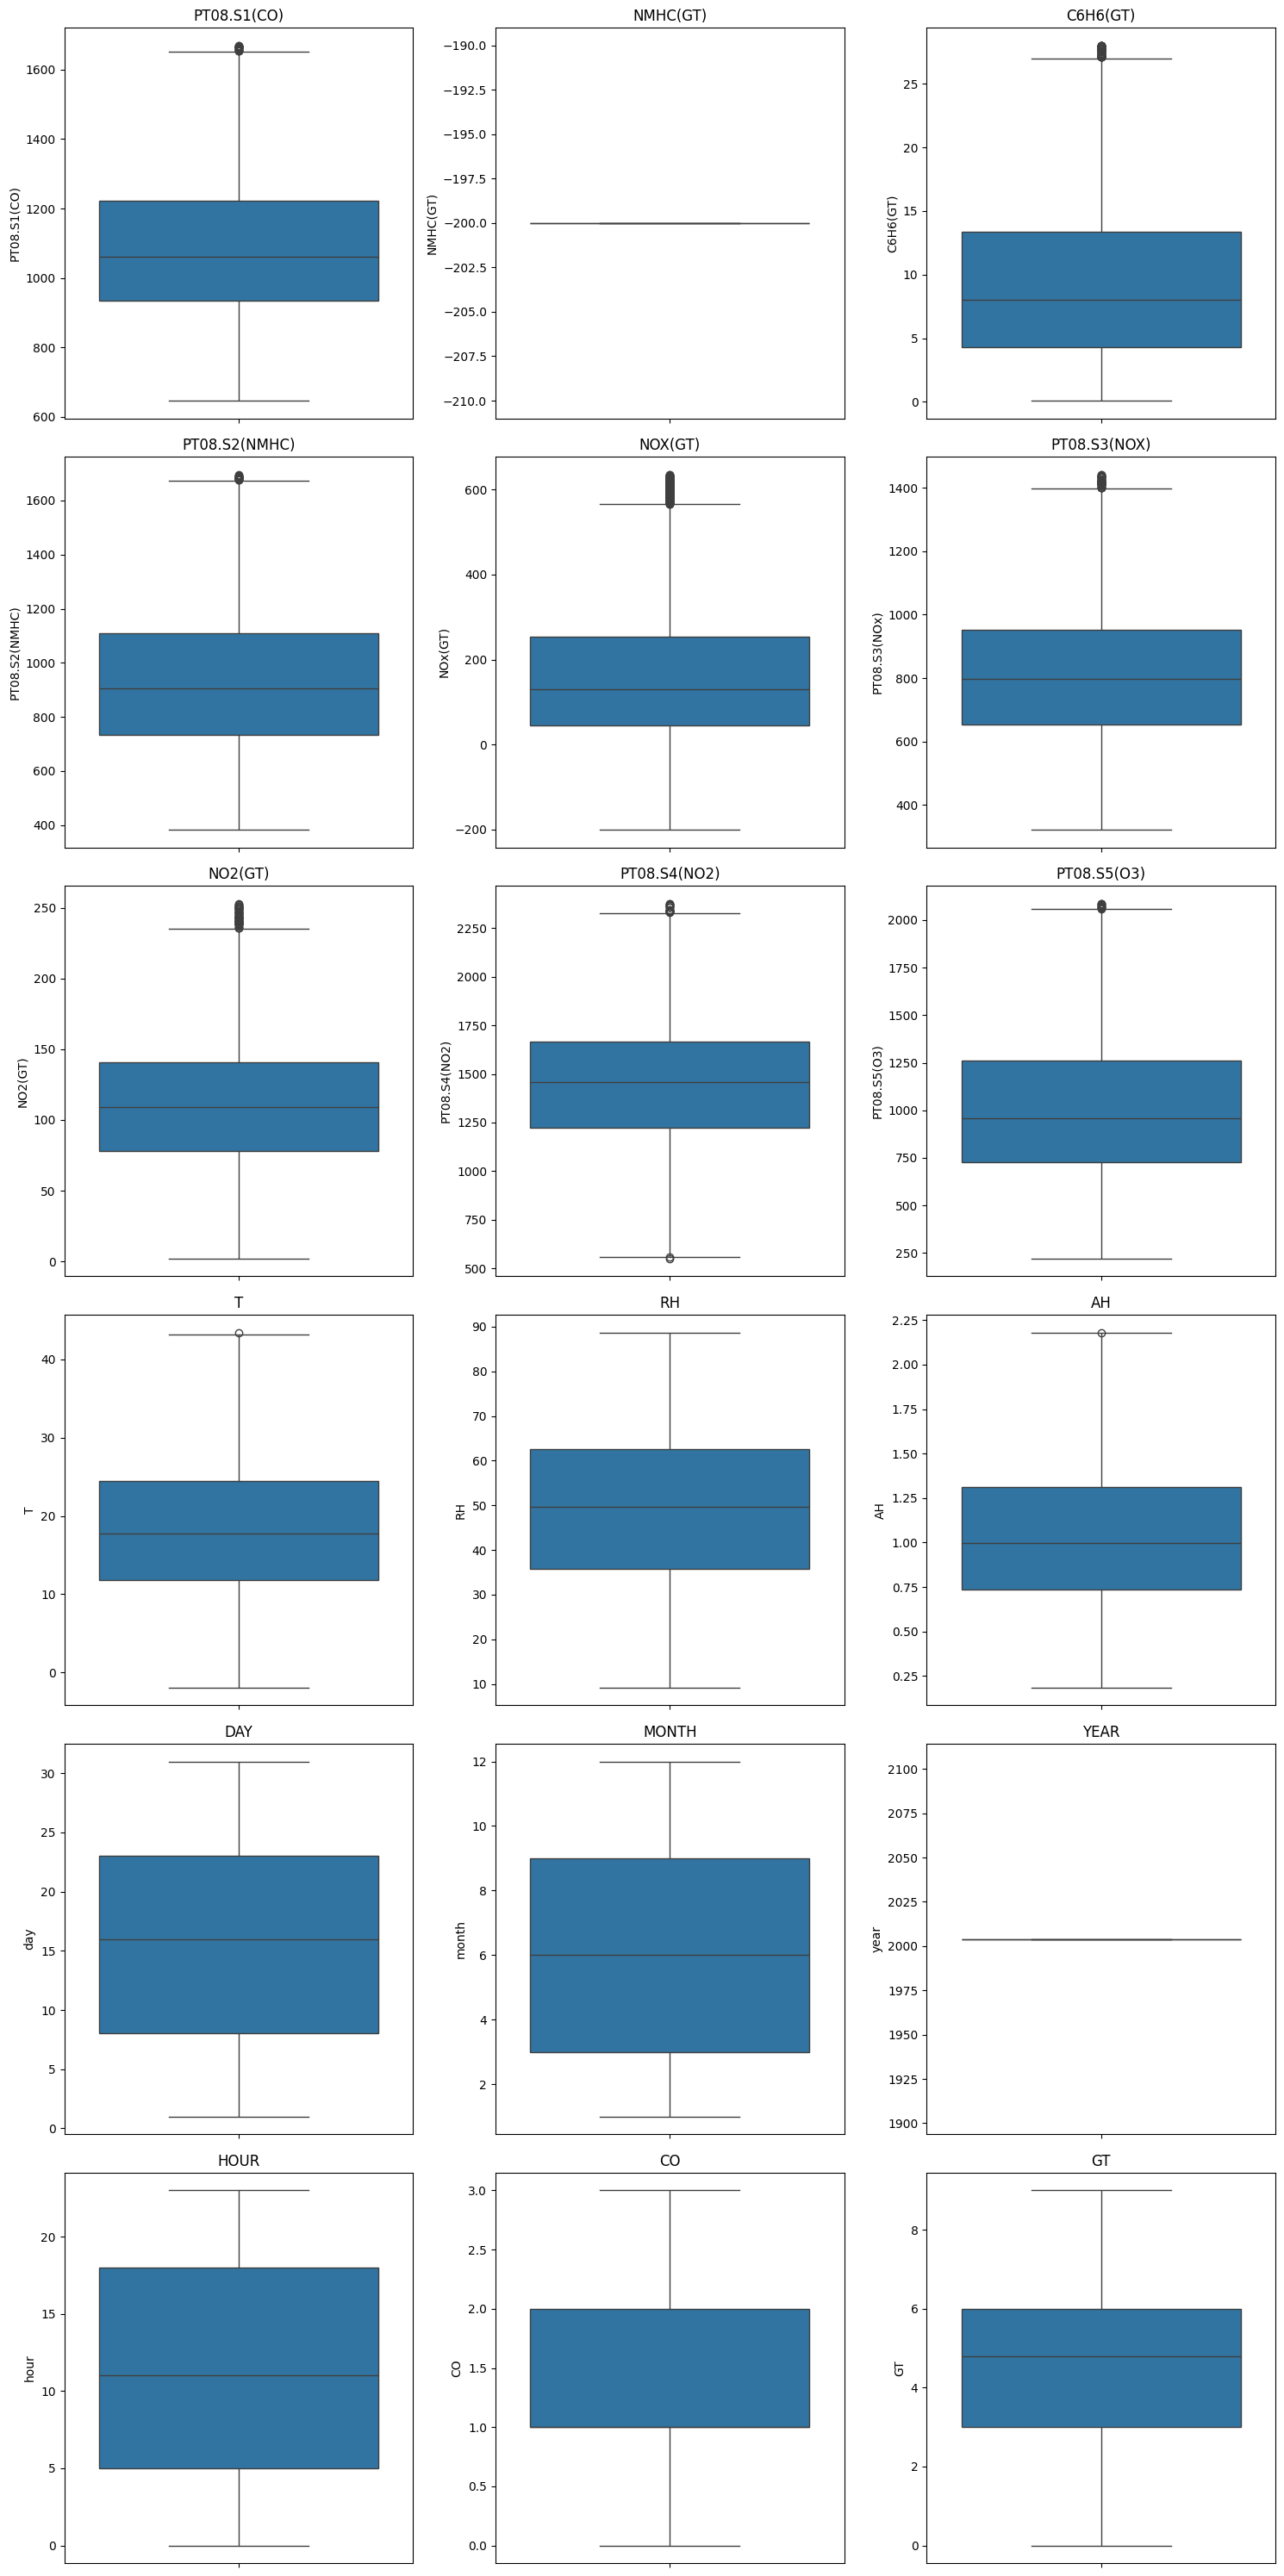

In [62]:
num_cols = len(df_copy.columns)
rows = (num_cols + 2) // 3  # 3 columns per row
plt.figure(figsize=(15, 5 * rows))

for i in range(num_cols):
    data = outlier(df_copy, df_copy.columns[i])
    plt.subplot(rows, 3, i + 1)
    sns.boxplot(data)
    plt.title(f'{df_copy.columns[i].upper()}')

plt.tight_layout()
plt.show()

In [63]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PT08.S1(CO)    9357 non-null   float64
 1   NMHC(GT)       9357 non-null   float64
 2   C6H6(GT)       9357 non-null   float64
 3   PT08.S2(NMHC)  9357 non-null   float64
 4   NOx(GT)        9357 non-null   float64
 5   PT08.S3(NOx)   9357 non-null   float64
 6   NO2(GT)        9357 non-null   float64
 7   PT08.S4(NO2)   9357 non-null   float64
 8   PT08.S5(O3)    9357 non-null   float64
 9   T              9357 non-null   float64
 10  RH             9357 non-null   float64
 11  AH             9357 non-null   float64
 12  day            9357 non-null   int32  
 13  month          9357 non-null   int32  
 14  year           9357 non-null   int32  
 15  hour           9357 non-null   int64  
 16  CO             9357 non-null   float64
 17  GT             9357 non-null   float64
dtypes: float

In [64]:
df_copy.describe()

,PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,day,month,year,hour,CO,GT
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604,15.876884,6.310356,2004.240141,11.498557,1.473763,4.803601
std,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670,8.808653,3.438160,0.427192,6.923182,1.177439,2.347520
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,1.000000,1.000000,2004.000000,0.000000,0.000000,0.000000
25%,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300,8.000000,3.000000,2004.000000,5.000000,1.000000,3.000000
50%,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800,16.000000,6.000000,2004.000000,11.000000,1.000000,4.803601
75%,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,23.000000,9.000000,2004.000000,18.000000,2.000000,6.000000
max,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,31.000000,12.000000,2005.000000,23.000000,5.000000,9.000000


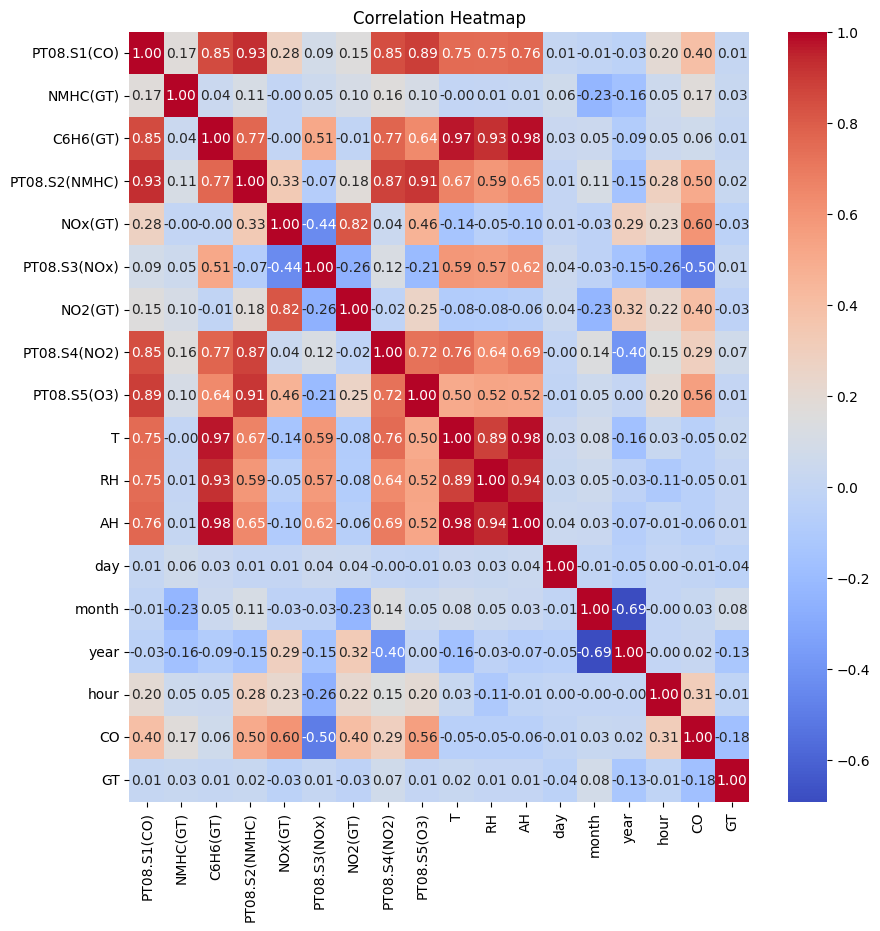

In [65]:
plt.figure(figsize=(10, 10))
sns.heatmap(df_copy.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

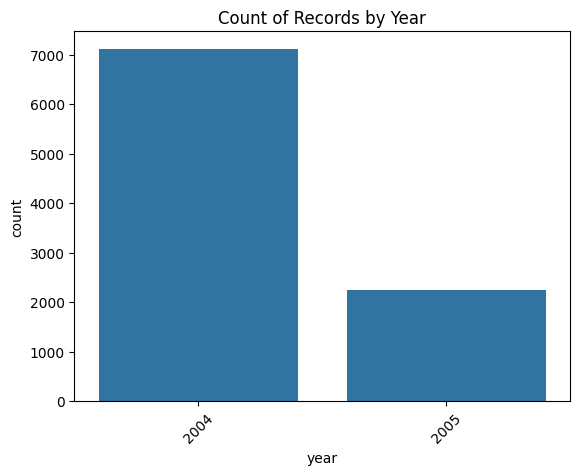

In [66]:
plt.Figure(figsize=(10, 6))
sns.countplot(x='year', data=df_copy)
plt.title('Count of Records by Year')
plt.xticks(rotation=45)
plt.show()

<Figure size 1000x600 with 0 Axes>

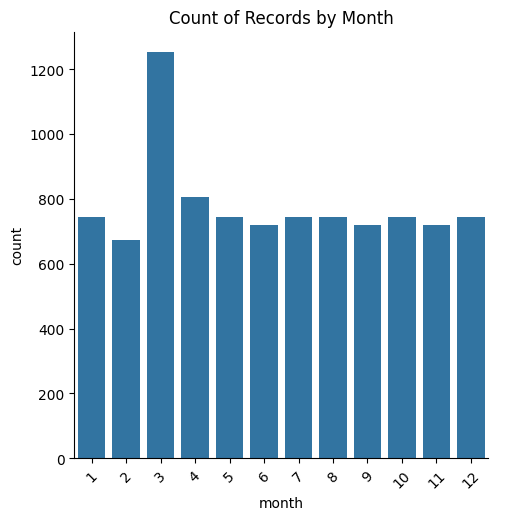

In [67]:
plt.figure(figsize=(10, 6))
sns.catplot(x='month', data=df_copy, kind='count')
plt.title('Count of Records by Month')
plt.xticks(rotation=45)
plt.show()